##Citibike - Predicting Daily Ridership 

E1: Load and Inspect

In [5]:
import sys
print('Python executable:', sys.executable)
import pandas
print('pandas version:', pandas.__version__, '- OK')

Python executable: c:\Users\Work\miniconda3\envs\da\python.exe
pandas version: 3.0.1 - OK


In [6]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


Load the CSV and inspect its structure: shape, dtypes, head. Confirm every column loaded as the type in the data dictionary — and document any that didn't, with your hypothesis for why.
 Tip: At least one column will not be the type you expect. Don't fix anything yet — eda.ipynb is for finding problems, preprocessing.ipynb is for fixing them.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/citibike_weather.csv')
df.head()

print("SHAPE:", df.shape)
print()



SHAPE: (1610, 10)



In [8]:
# Inspect the first few rows of the DataFrame
print("HEAD:")
print(df.head())

HEAD:
    ride_date  num_rides  avg_duration_min  temp_f  max_temp_f  min_temp_f  \
0  2013-07-01      16650         16.309988    74.8        78.1        73.4   
1  2013-07-02      22745         15.968826    76.1        82.9        73.0   
2  2013-07-03      21864         16.238808    78.5        84.9        73.9   
3  2013-07-04      22326         21.218474    82.0        91.0        73.9   
4  2013-07-05      21842         18.040443    84.4        93.0        75.9   

   wind_speed_knots  precip_in day_of_week  month  
0               7.8       0.00      Monday      7  
1               8.0       0.73     Tuesday      7  
2               8.8       0.06   Wednesday      7  
3               8.6       0.96    Thursday      7  
4               9.0       0.00      Friday      7  


In [3]:
# Inspect each column's pandas dtype
dtypes = df.dtypes
print(dtypes)

ride_date               str
num_rides             int64
avg_duration_min    float64
temp_f              float64
max_temp_f          float64
min_temp_f          float64
wind_speed_knots    float64
precip_in           float64
day_of_week             str
month                 int64
dtype: object


#E1 Findings: ride_date loaded as a str not date

#E2: Profile the Distributions

Run .describe() on the numeric columns and plot a histogram of each. For every column, ask: are the min and max physically possible? 

Document anything suspicious.
 Tip: Government datasets often encode missing values as numbers rather than leaving cells blank. NOAA's GSOD documentation says missing observations are coded as 9999.9 (temperatures), 999.9 (wind), or 99.99 (precipitation). A careful analyst checks whether any of those codes made it into their slice of the data.


In [11]:
df.describe()

,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,month
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,32986.783230,15.425627,57.368509,67.317081,49.295901,9.013913,0.178398,6.544099
std,16910.147968,3.652633,17.876211,18.349408,17.832318,3.241211,2.508762,3.323772
min,876.000000,9.495396,8.300000,18.000000,1.000000,2.300000,0.000000,1.000000
25%,20505.500000,13.112342,43.625000,53.700000,35.700000,6.700000,0.000000,4.000000
50%,32272.500000,14.860057,59.300000,70.000000,51.100000,8.500000,0.000000,7.000000
75%,42915.750000,17.121551,73.500000,82.900000,64.900000,10.800000,0.060000,9.000000
max,78458.000000,81.110084,92.500000,100.900000,82.900000,22.400000,99.990000,12.000000


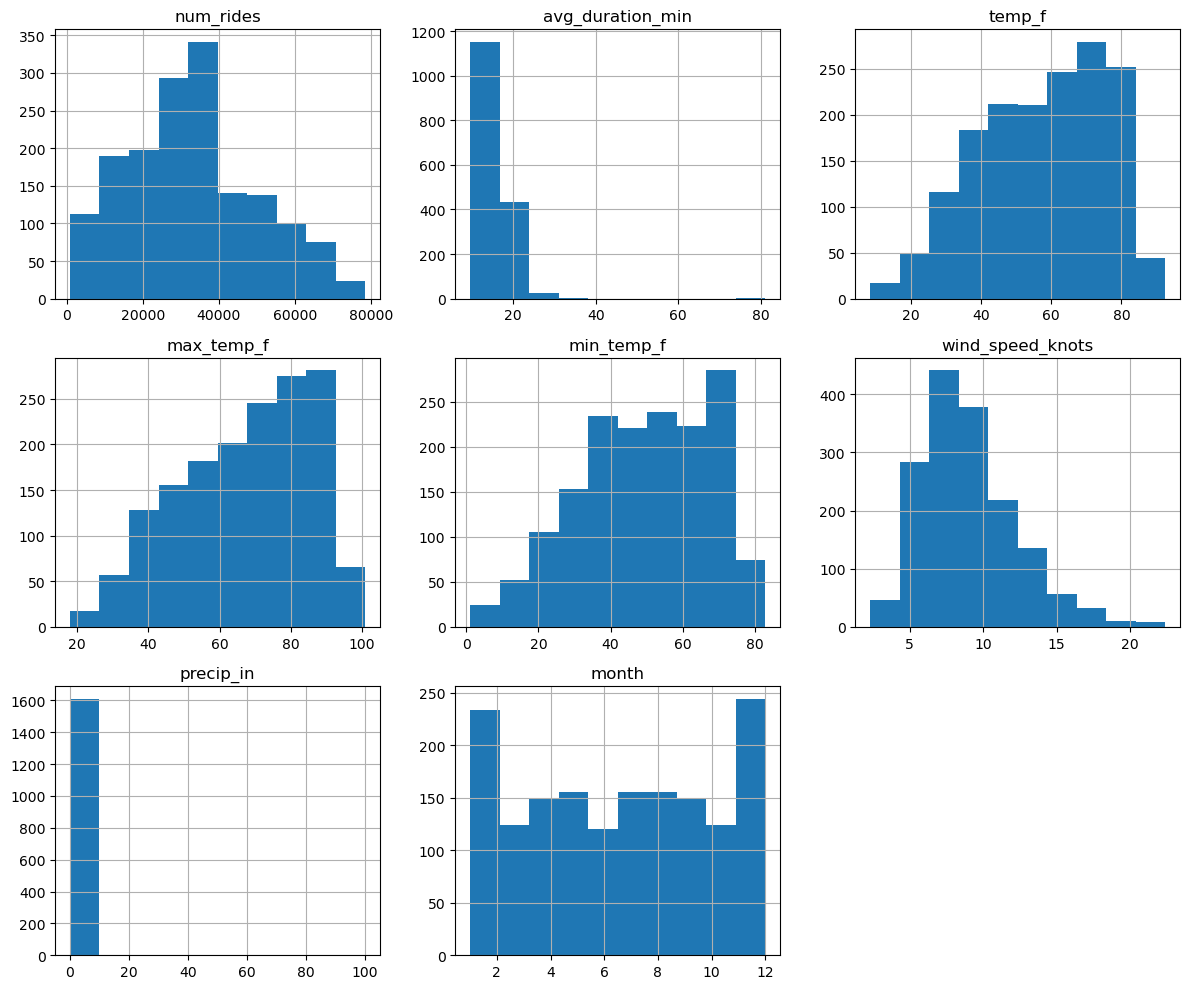

In [12]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

#E2 Findings: Precip_in has 99.99 max. Data is missing.

##E3: Relationships With the Target
Make scatter plots of num_rides against each weather variable. Which relationships look strong? Which look weak? Describe the shape of the temperature relationship in a markdown cell.
 Tip: Look closely at the very hottest days. Does ridership keep climbing forever as it gets hotter, or does something else happen? Remember this when you get to feature engineering.



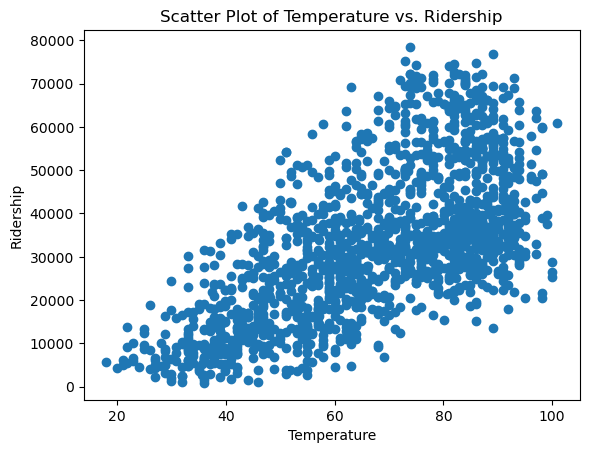

In [16]:
#scatter plot of temperature vs. ridership
plt.scatter(df['max_temp_f'], df['num_rides'])
plt.xlabel('Temperature')
plt.ylabel('Ridership')
plt.title('Scatter Plot of Temperature vs. Ridership')
plt.show()

#E3 Findings: 

##E4: Ridership Over Time
Plot num_rides over the full date range. Then compare the same month across different years — for example, average July ridership in 2013 vs. 2015 vs. 2017.
In a markdown cell: is a July day in 2017 the same as a July day in 2013, even at identical weather? What does that mean for a model whose only inputs are weather and day-of-week?
 Tip: The bike share system itself changed over these six years: more stations, more bikes, more members. Your model needs some way to know what year it is.



In [19]:
df['ride_date_parsed'] = pd.to_datetime(df['ride_date'])
print("Date range:", df['ride_date_parsed'].min(), "to", df['ride_date_parsed'].max())
print()

july= df[df['month'] == 7].copy()
july['year'] = july['ride_date_parsed'].dt.year
print("July average num_rides by year:")
print(july.groupby('year')['num_rides'].mean())

Date range: 2013-07-01 00:00:00 to 2018-05-31 00:00:00

July average num_rides by year:
year
2013    27206.967742
2014    31252.967742
2015    35021.806452
2016    44519.677419
2017    55987.064516
Name: num_rides, dtype: float64


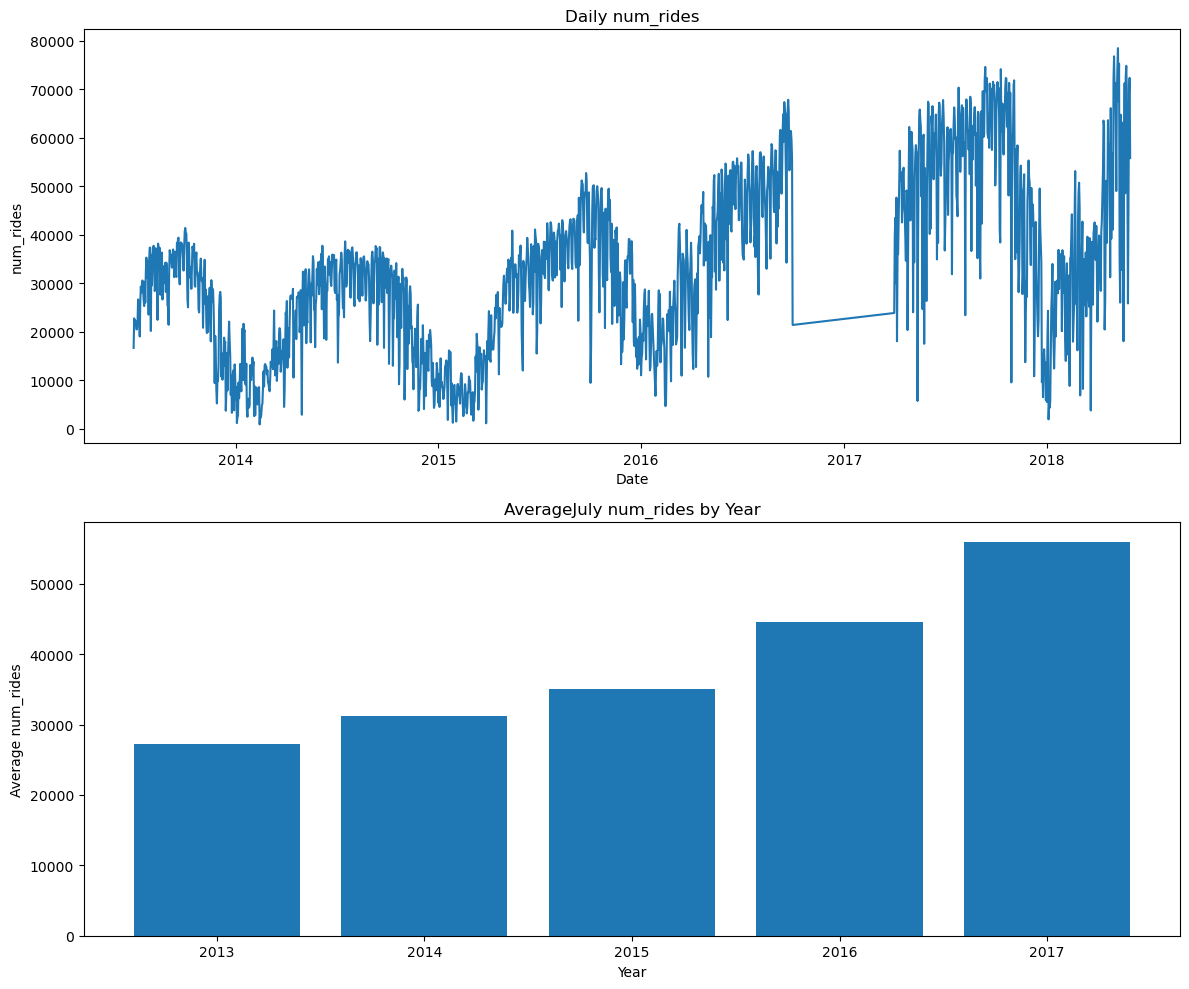

In [25]:
#plot of ridership over time
from matplotlib import axes


df['ride_date_parsed'] = pd.to_datetime(df['ride_date'])
df = df.sort_values('ride_date_parsed')
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

axes[0].plot(df['ride_date_parsed'], df['num_rides'])
axes[0].set_ylabel('num_rides')
axes[0].set_xlabel('Date')
axes[0].set_title('Daily num_rides')

july = df[df['month'] == 7].copy()
july['year'] = july['ride_date_parsed'].dt.year
july_means = july.groupby('year')['num_rides'].mean()
axes[1].bar(july_means.index, july_means.values)
axes[1].set_ylabel('Average num_rides')
axes[1].set_xlabel('Year')
axes[1].set_title('AverageJuly num_rides by Year') 

plt.tight_layout()

#E4 Findings: Ridership peaks during the summer but 2017 ridership doubled. 
There's a straight line across a gap in the data. Maybe missing dates. 

##E5: The Weekly Rhythm
Compare ridership across days of the week (a bar chart of the mean, or box plots, work well). Which days are busiest? Does the weekday/weekend pattern match your intuition about who rides Citi Bike and why?



#E6: The Missing Days
Your table should have roughly 1,610 rows — but the date range it spans contains more days than that. Compute exactly how many dates between the min and max are missing from your data, and look at WHERE the gaps fall. Offer a hypothesis for what happened, and recall from Part 1 which side of the join these gaps came from.
 Tip: pd.date_range() gives you every date in a span; compare it against the dates you actually have.



In [26]:
df['ride_date_parsed'] = pd.to_datetime(df['ride_date'])

full_range = pd.date_range(df['ride_date_parsed'].min(), df['ride_date_parsed'].max())
have = set(df['ride_date_parsed'])
missing = sorted(set(full_range) - have)

print("Full range span:", len(full_range), "days")
print("Rows we actually have:", len(df))
print("Missing dates:", len(missing))
print()
print("First missing:", missing[0])
print("Last missing:", missing[-1])

Full range span: 1796 days
Rows we actually have: 1610
Missing dates: 186

First missing: 2016-01-23 00:00:00
Last missing: 2017-03-31 00:00:00


In [27]:
df['ride_date_parsed'] = pd.to_datetime(df['ride_date'])

full_range = pd.date_range(df['ride_date_parsed'].min(), df['ride_date_parsed'].max())
have = set(df['ride_date_parsed'])
missing = sorted(set(full_range) - have)
missing_series = pd.Series(missing)

# check contiguity - group consecutive missing dates into blocks
blocks = []
block_start = missing_series[0]
prev = missing_series[0]
for d in missing_series[1:]:
    if (d - prev).days > 1:
        blocks.append((block_start, prev))
        block_start = d
    prev = d
blocks.append((block_start, prev))

print(f"Number of separate missing-date blocks: {len(blocks)}")
for b in blocks:
    span = (b[1]-b[0]).days + 1
    print(f"  {b[0].date()} to {b[1].date()}  ({span} days)")

Number of separate missing-date blocks: 2
  2016-01-23 to 2016-01-26  (4 days)
  2016-10-01 to 2017-03-31  (182 days)


#E6 Findings: That range 07-01-2013 to 05-31-2018 counts 1796 days. The data set has 1610 rows, missing 186 dates